<a href="https://colab.research.google.com/github/Abarre71/STAT-7110-Quality-Control/blob/main/ewma_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The EWMA Control Chart
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Recap: Why We Needed More Than the Shewhart Chart](#recap-why-we-needed-more-than-the-shewhart-chart)
2. [The EWMA Chart](#the-ewma-chart)
3. [Foundations of the EWMA Chart](#foundations-of-the-ewma-chart)
4. [The Mean and Variance of $z_i$](#the-ewma-chart--the-mean)
5. [Control Limits & Steady-State Limits](#the-ewma-chart--control-limits)
6. [Choosing $L$ and $\lambda$](#choosing-l-and-lambda)
7. [Worked Example: Soda Bottles](#the-ewma-chart-in-r)
8. [Additional Examples](#the-ewma-chart--additional-example-customer-hold-times)
9. [Phase I Considerations](#the-ewma-chart--phase-i-considerations)
10. [Correlated Observations](#the-ewma-chart--correlated-observations)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "Abarre71"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

#setwd("Slides//Week-5-EWMA")

[1] "Repository already cloned to Colab."


## Recap: Why We Needed More Than the Shewhart Chart

Last week we met the **CUSUM** chart, built to fix a real blind spot in the Shewhart $\bar{X}$ chart: its insensitivity to small shifts ($\leq 2\sigma$) in the process mean, and its inefficient, one-point-at-a-time use of the data.

| Chart | Sensitive to small shifts? | Simple to implement & interpret? |
|---|:---:|:---:|
| Shewhart $\bar{X}$ | ❌ | ✅ |
| CUSUM | ✅ | ❌ — tracking $C^+$/$C^-$ and picking $H$, $K$ takes some getting used to |

That leaves an obvious gap: a chart that keeps CUSUM's sensitivity to small, sustained shifts, but is as easy to read as a Shewhart chart. This week, that's the **Exponentially Weighted Moving Average (EWMA)** chart.

## The EWMA Chart

The EWMA chart was proposed by [Roberts (1959)](https://www.scirp.org/reference/referencespapers?referenceid=1374838), and if the name sounds familiar outside of quality control, that's because it should. Exponentially weighted moving averages are the same machinery behind smoothing stock prices, forecasting demand, and even the "recent form" ratings used in sports analytics. The same idea, weighting recent data more heavily, but don't throw away the past, turns out to be just as useful for spotting a drifting process mean.

Like CUSUM, the EWMA chart is designed to catch small shifts in the process mean and draws on the entire sequence of points rather than just the latest one. But it's noticeably **simpler to implement and interpret** than CUSUM.

The key difference: where CUSUM's plotting statistic is built from the *deviations* away from target, EWMA "weights" the observations themselves to produce a moving average. That makes it a bit more intuitive to read as the plotted value is a function of the observed values, not the observed deviances.

## Foundations of the EWMA Chart

Say we take a random sample ($n \geq 1$) and calculate a sample mean (or use the individual value directly when $n=1$) — call this value $x_i$.

The plotting statistic for the EWMA chart is defined recursively:

$$ z_i = \lambda x_i + (1-\lambda)z_{i-1} $$

where $0 < \lambda \leq 1$ and $z_{0} = \mu_0$. With some rearranging, $z_i$ turns out to be a weighted average of *all* previously observed $x_i$'s, with exponentially decaying weight on older observations:

$$ z_i = \lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}x_{i-j} + (1-\lambda)^iz_0 $$

To build control limits, we now need the mean and variance of $z_i$.

## The EWMA Chart — The Mean

$$ E[z_i] = E\bigg[\lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}x_{i-j} + (1-\lambda)^iz_0\bigg] $$

$$ \implies \lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}E[x_{i-j}] + (1-\lambda)^iE[z_0] $$

$$ \implies \lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}\mu_0 + (1-\lambda)^i\mu_0 = \mu_0 $$

Reassuring, but unsurprising: as a weighted average of on-target observations, $z_i$ is centered right where we'd expect — at $\mu_0$.

## The EWMA Chart — The Variance

$$ \sigma^2_{z_i} = Var[z_i] = Var\bigg[\lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}x_{i-j} + (1-\lambda)^iz_0\bigg] $$

$$ \implies \lambda^2\sum_{j=0}^{i-1}(1-\lambda)^{2j}Var[x_{i-j}] $$

$$ \implies \sigma^2_{z_i} = \sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)\big(1-(1-\lambda)^{2i}\big) $$

Unlike the CUSUM's running sum, this variance doesn't grow without bound — it's shrunk by the $\frac{\lambda}{2-\lambda}$ factor and converges as $i$ grows, which is exactly what makes stable control limits possible.

## The EWMA Chart — Control Limits

Putting the mean and variance together, our control limits are:

$$ UCL = \mu_0 + L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)\big(1-(1-\lambda)^{2i}\big)} $$
$$ LCL = \mu_0 - L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)\big(1-(1-\lambda)^{2i}\big)} $$

Notice these limits depend on $i$ — early in the chart, they'll be tighter around $\mu_0$ and will widen slightly as more points accumulate.

## The EWMA Chart — Steady-State Limits

As $i\rightarrow\infty$, the $(1-\lambda)^{2i}$ term vanishes and the limits settle down to:

$$ UCL = \mu_0 + L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)} $$
$$ LCL = \mu_0 - L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)} $$

These are the "steady state" limits, typically reached around $i = 20-30$. That said, it's strongly recommended to use the exact (time-varying) limits for smaller values of $i$ — using the wider steady-state limits too early can hide a shift that shows up in the first handful of observations.

## Choosing $L$ and $\lambda$

The general rule of thumb: smaller $\lambda$ → more sensitive to small shifts (more weight on history), larger $\lambda$ → the chart behaves more like a Shewhart chart (more weight on the most recent point).

$L=3$, as in a Shewhart-style chart, works reasonably well and gives $ARL_0 \approx 500$. More precise pairings of $L$ and $\lambda$ were worked out by [Lucas and Saccucci (1990)](https://www.tandfonline.com/doi/abs/10.1080/00401706.1990.10484583):

## Choosing $L$ and $\lambda$ — ARL Table

**ARL Values for the EWMA Control Chart**

| Shift in Mean (multiple of $\sigma$) | $L=3.054$, $\lambda=0.40$ | $L=2.998$, $\lambda=0.25$ | $L=2.962$, $\lambda=0.20$ | $L=2.814$, $\lambda=0.10$ | $L=2.615$, $\lambda=0.05$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 500 | 500 | 500 | 500 | 500 |
| 0.25 | 224 | 170 | 150 | 106 | 84.1 |
| 0.50 | 71.2 | 48.2 | 41.8 | 31.3 | 28.8 |
| 0.75 | 28.4 | 20.1 | 18.2 | 15.9 | 16.4 |
| 1.00 | 14.3 | 11.1 | 10.5 | 10.3 | 11.4 |
| 1.50 | 5.9 | 5.5 | 5.5 | 6.1 | 7.1 |
| 2.00 | 3.5 | 3.6 | 3.7 | 4.4 | 5.2 |
| 3.00 | 2.0 | 2.3 | 2.4 | 2.9 | 3.5 |


## The EWMA Chart in R

Let's revisit the soda bottles example from last week: filling bottles with a target of $\mu_0 = 16$ oz, sampling 5 bottles every hour for two days (48 hours). This time, we'll use $\lambda = 0.20$ and $L = 2.962$ — one of the pairings from the Lucas and Saccucci table above.

In [ ]:
## Load the libraries ##
install.packages(c('tidyverse','readxl','qcc'))
library(tidyverse)
library(readxl)
library(qcc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



### Read in the Soda Bottles data

In [ ]:
getwd()
bottles <- read_xlsx("/content/STAT-7110-Quality-Control/Slides/Week-5-EWMA/Soda Bottles.xlsx")

bottles |>
  glimpse()

[1] "/content"

Rows: 48
Columns: 5
$ `Bottle 1` <dbl> 15.78, 16.35, 16.03, 16.08, 16.10, 16.14, 16.09, 16.13, 16.…
$ `Bottle 2` <dbl> 16.14, 16.05, 16.19, 16.31, 16.55, 16.22, 16.13, 16.18, 16.…
$ `Bottle 3` <dbl> 15.94, 15.80, 16.08, 15.96, 16.06, 15.98, 15.92, 16.44, 16.…
$ `Bottle 4` <dbl> 16.19, 16.12, 16.38, 16.13, 16.23, 16.24, 16.42, 16.32, 16.…
$ `Bottle 5` <dbl> 16.53, 16.03, 16.29, 16.28, 16.26, 15.76, 16.40, 16.20, 16.…


### Calculate the overall SD and set the target

In [ ]:
sigma_hat <- sd.xbar(bottles,std.dev="UWAVE-SD")

mu0 <- 16

### Calculate the EWMA values manually before using the `qcc` function

In [ ]:
lambda <- 0.20
L <- 2.962

EWMA_df <- tibble(Means = rowMeans(bottles))

### Calculate the EWMA values

In [ ]:
ewma_values <- vector('double',length=nrow(EWMA_df))

for(i in 1:length(ewma_values)){

  if(i==1){

    ewma_values[i] <- lambda*EWMA_df$Means[i] + (1-lambda)*mu0

  } else {

    ewma_values[i] <- lambda*EWMA_df$Means[i] + (1-lambda)*ewma_values[i-1]

  }

}

### Calculate SD for EWMA

In [ ]:
sd_ewma <- vector('double',length=nrow(EWMA_df))

for(i in 1:length(sd_ewma)){

  sd_ewma[i] <- sigma_hat^2/5*(lambda/(2-lambda))*(1-(1-lambda)^(2*i))

}

### Calculate the UCL and LCL

In [ ]:
EWMA_df <- EWMA_df |>
  mutate(`EWMA Values` = ewma_values,
         Variance = sd_ewma,
         UCL = mu0 + L*sqrt(Variance),
         LCL = mu0 - L*sqrt(Variance)
  )

### Plot the manually-calculated EWMA chart

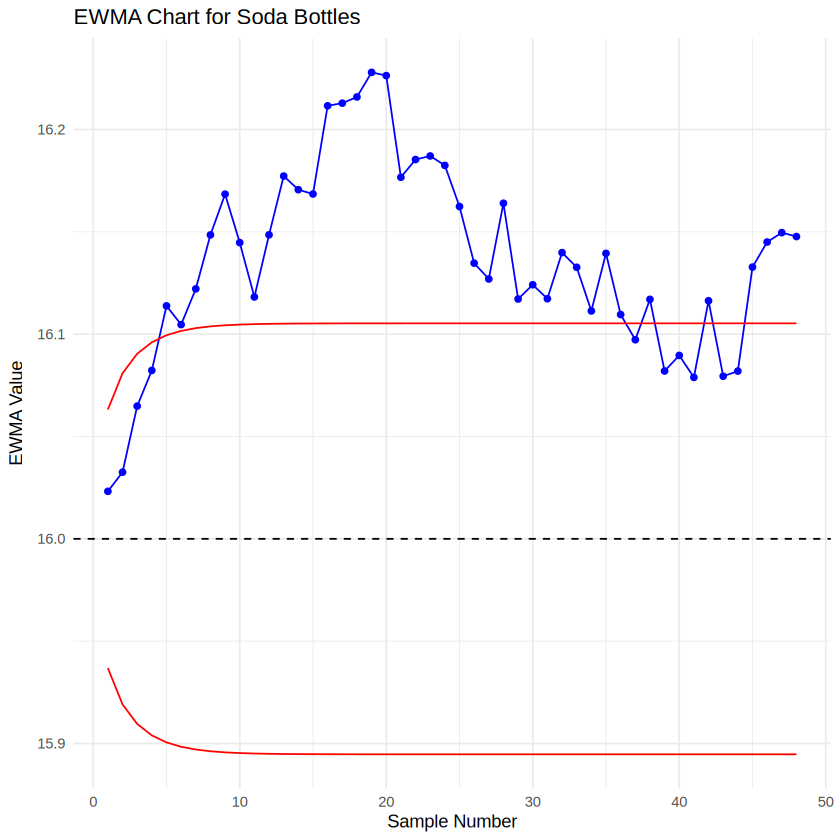

In [ ]:
EWMA_df |>
  ggplot(aes(x=1:nrow(EWMA_df))) +
  geom_line(aes(y=`EWMA Values`),color="blue") +
  geom_point(aes(y=`EWMA Values`),color="blue",size=1.5) +
  geom_line(aes(y=UCL),color="red") +
  geom_line(aes(y=LCL),color="red") +
  geom_hline(yintercept=mu0,linetype="dashed") +
  labs(title="EWMA Chart for Soda Bottles",
       x="Sample Number",
       y="EWMA Value") +
  theme_minimal()

### Now let's do this using the `qcc` package

List of 15
 $ call      : language ewma(data = bottles, center = 16, lambda = 0.2, nsigmas = 2.962)
 $ type      : chr "ewma"
 $ data.name : chr "bottles"
 $ data      : num [1:48, 1:5] 15.8 16.4 16 16.1 16.1 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:48] 16.1 16.1 16.2 16.2 16.2 ...
  ..- attr(*, "names")= chr [1:48] "1" "2" "3" "4" ...
 $ sizes     : int [1:48] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.237
 $ x         : int [1:48] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:48] 16 16 16.1 16.1 16.1 ...
  ..- attr(*, "names")= chr [1:48] "1" "2" "3" "4" ...
 $ sigma     : num [1:48] 0.0212 0.0272 0.0304 0.0322 0.0334 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:48, 1:2] 15.9 15.9 15.9 15.9 15.9 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:38] 5 6 7 8 9 10 11 12 13 14 ...
  ..- attr(*, "names")= chr [1:38] "5" "6" "7" "8" ...
 - attr(*, "class")= chr "ewma.qcc"

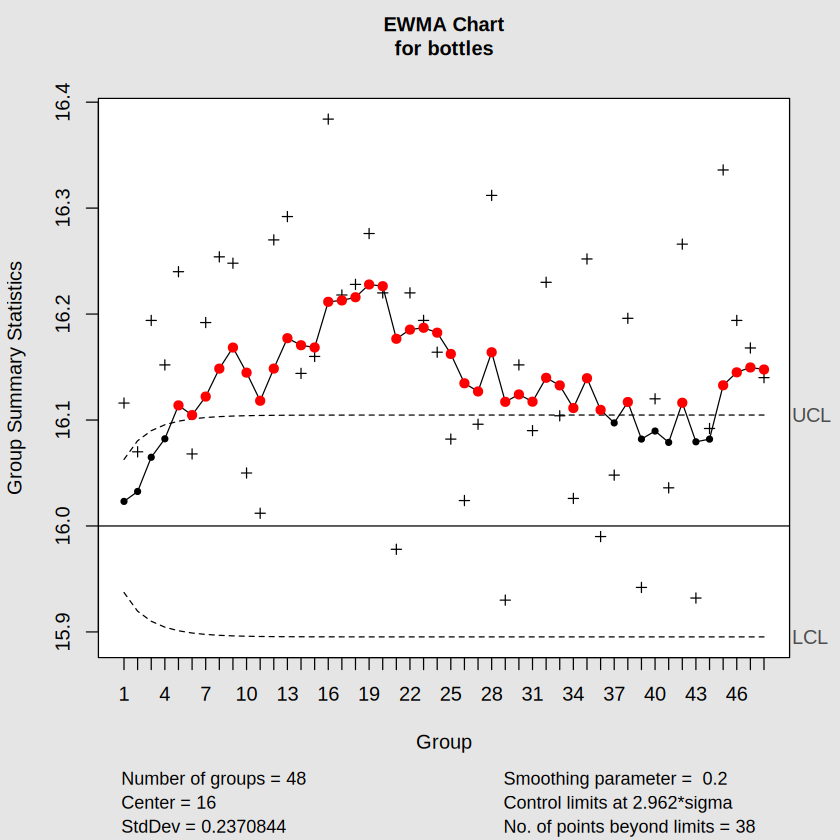

In [ ]:
ewma(bottles,center=16,lambda=0.2,nsigmas=2.962)

The key thing to remember with both the CUSUM and EWMA charts: `qcc` assumes you're working with the sample mean. So don't forget that $Var[\bar{X}] = Var[X]/n$ — mixing this up is one of the more common sources of charts that look "too tight" or "too loose" in practice.

## The EWMA Chart — Additional Example: Customer Hold Times

Let's monitor the amount of time customers spend on hold at a customer service support center — the kind of metric a modern support team would track on a live dashboard. Suppose the target hold time is $\mu_0 = 10$ and $\sigma = 1$. Here $n=1$, so there's no sample mean to worry about — we're monitoring individual observations directly.

Data for the most recent 30 customers placed on hold are contained in this week's Excel spreadsheet.

In [ ]:
customer_hold <- read_xlsx("/content/STAT-7110-Quality-Control/Slides/Week-5-EWMA/EWMA Datasets.xlsx",sheet=1)

customer_hold |>
  glimpse()

Rows: 30
Columns: 2
$ Call <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19…
$ Time <dbl> 9.45, 7.99, 9.29, 11.66, 12.16, 10.18, 8.04, 11.46, 9.20, 10.34, …


List of 15
 $ call      : language ewma(data = customer_hold$Time, center = 10, lambda = 0.2, nsigmas = 2.962,      sigma = 1)
 $ type      : chr "ewma"
 $ data.name : chr "customer_hold$Time"
 $ data      : num [1:30, 1] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:30] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sizes     : int [1:30] 1 1 1 1 1 1 1 1 1 1 ...
 $ center    : num 10
 $ std.dev   : num 1.2
 $ x         : int [1:30] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:30] 9.89 9.51 9.47 9.9 10.36 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sigma     : num [1:30] 0.24 0.307 0.344 0.365 0.378 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:30, 1:2] 9.29 9.09 8.98 8.92 8.88 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int(0) 
  ..- attr(*, "names")= chr(0) 
 - attr(*, "class")= chr "ewma.qcc"

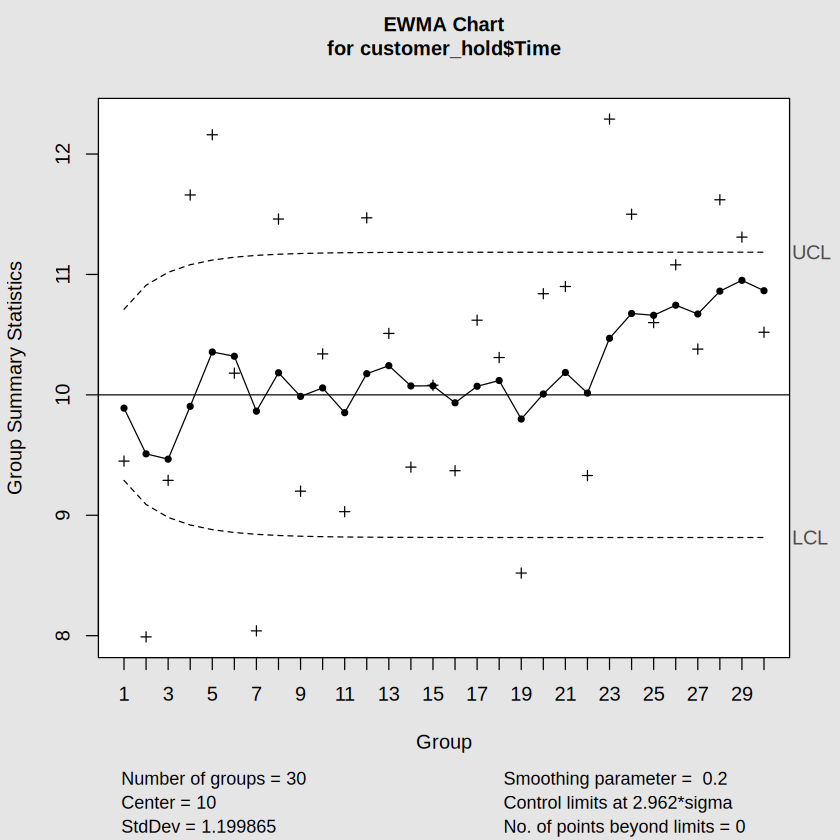

In [ ]:
ewma(customer_hold$Time,center=10,sigma = 1,lambda=0.2,nsigmas=2.962)

## The EWMA Chart — Phase I Considerations

What about Phase I? Unlike some of our earlier charts, EWMA doesn't lean heavily on distributional assumptions. The main things we care about are independence of observations and having a good estimate of the process mean and standard deviation.

In the last example we assumed $\mu_0$ and $\sigma$ were known. But what if they're not? We still need to confirm the process is in statistical control before moving on to Phase II. So let's estimate them from data and check.

Let's run through the Dunder-Mifflin example again. As a reminder, in order for our branch to be profitable, we need to maximize sales and control our operating costs. One such operating cost is the amount of fuel our warehouse delivery trucks use. In the second sheet of this week's class data, we have the past 24 months of fuel costs. Let's estimate the mean and standard deviation and see if the process is in control.

In [ ]:
fuel_costs <- read_xlsx("/content/STAT-7110-Quality-Control/Slides/Week-5-EWMA/EWMA Datasets.xlsx",sheet=2)

fuel_costs |>
  glimpse()

Rows: 24
Columns: 2
$ Cost  <dbl> 5525.27, 5084.35, 4021.17, 4923.73, 5254.42, 5404.45, 4843.34, 5…
$ month <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9…


### Estimate the process mean and standard deviation

In [ ]:
## Estimate process mean ##

mu0 <- mean(fuel_costs$Cost)

## Estimate process standard deviation ##

sigma_hat <- sd(fuel_costs$Cost)

List of 15
 $ call      : language ewma(data = fuel_costs$Cost, center = mu0, lambda = 0.2, nsigmas = 2.962,      sigma = sigma_hat)
 $ type      : chr "ewma"
 $ data.name : chr "fuel_costs$Cost"
 $ data      : num [1:24, 1] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 1 1 1 1 1 1 1 1 1 1 ...
 $ center    : num 5001
 $ std.dev   : num 395
 $ x         : int [1:24] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:24] 5106 5101 4885 4893 4965 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sigma     : num [1:24] 79 101 113 120 124 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:24, 1:2] 4767 4701 4666 4645 4632 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int(0) 
  ..- attr(*, "names")= chr(0) 
 - attr(*, "class")= chr "ewma.qcc"

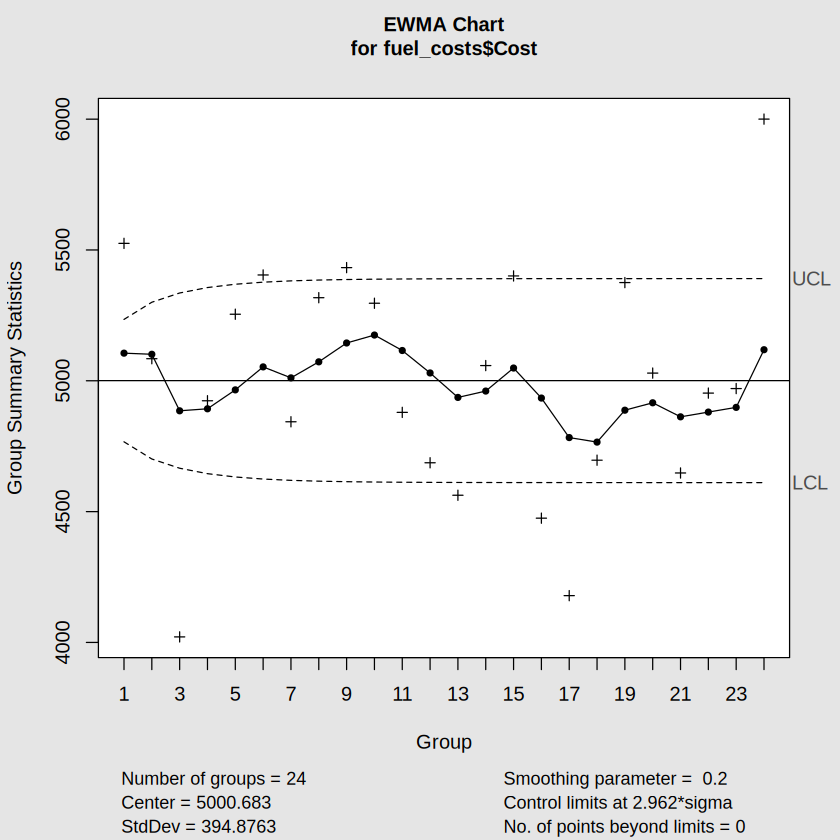

In [ ]:
ewma(fuel_costs$Cost,center=mu0,sigma=sigma_hat,lambda=0.2,nsigmas=2.962)

Same conclusion as with the CUSUM chart: the process appears to be in control! It's a good sign when two different monitoring approaches agree; it gives us more confidence in the call.

## The EWMA Chart — Correlated Observations

One of the main assumptions of the EWMA chart, and really all of the charts we've covered so far, is that observations are independent of each other (no covariance/correlation between two observations).

What happens if that's not reasonably met? The chart's ARL performance suffers. Here's why: if two variables are dependent, the variance of their sum is:

$$ Var[X+Y] = Var[X] + Var[Y] + 2\,COV[X,Y] $$

Depending on the direction of that relationship, variance could go up or down:

| Correlation | Effect on variance | Practical consequence |
|---|---|---|
| Positive | Variance is **larger** than the EWMA chart assumes | False alarm rate $\alpha$ increases — but the chart also becomes very sensitive to small shifts |
| Negative | Variance is **smaller** than the EWMA chart assumes | False alarm rate becomes tiny, and the chart becomes very insensitive to real shifts |

This is exactly the kind of thing that trips people up when they apply EWMA to autocorrelated data: Sensor readings sampled too frequently, or web traffic metrics with strong time-of-day patterns, for example. It's important to be reasonably confident your observations aren't significantly correlated before leaning on this chart.

Much research has been done in this space. For interested students, especially Ph.D. students, I'd recommend reading:

1. [Montgomery and Mastrangelo (1991)](https://www.tandfonline.com/doi/abs/10.1080/00224065.1991.11979321)
2. [Vanbrackle and Reynolds (1997)](https://www.tandfonline.com/doi/abs/10.1080/03610919708813421)
3. [Psarakis and Papaleonida (2007)](https://www.tandfonline.com/doi/abs/10.1080/16843703.2007.11673168)
4. [Tyagi and Yadav (2021)](https://journals.riverpublishers.com/index.php/JRSS/article/view/20337)